Binning is a data transformation technique where you convert continuous numerical data into discrete categories (bins or intervals).

In [1]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import KBinsDiscretizer
import matplotlib.pyplot as plt

import math

In [2]:
df = pd.read_csv('sample_dataset.csv').iloc[:,0:5].dropna()
df


,mean radius,mean texture,mean perimeter,mean area,mean smoothness
2,19.69,21.25,130.00,1203.0,0.10960
3,11.42,20.38,77.58,386.1,0.14250
8,13.00,21.82,87.50,519.8,0.12730
13,15.85,23.95,103.70,782.7,0.08401
14,13.73,22.61,93.60,578.3,0.11310
...,...,...,...,...,...
549,10.82,24.21,68.89,361.6,0.08192
550,10.86,21.48,68.51,360.5,0.07431
560,14.05,27.15,91.38,600.4,0.09929
564,21.56,22.39,142.00,1479.0,0.11100


In [3]:
binner = KBinsDiscretizer(strategy='uniform',n_bins=5)

In [4]:
binner.fit_transform(df)

c:\Users\Cheru\anaconda3\ana\Lib\site-packages\sklearn\preprocessing\_discretization.py:239: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


<176x25 sparse matrix of type '<class 'numpy.float64'>'
	with 880 stored elements in Compressed Sparse Row format>

c:\Users\Cheru\anaconda3\ana\Lib\site-packages\sklearn\preprocessing\_discretization.py:239: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(
c:\Users\Cheru\anaconda3\ana\Lib\site-packages\sklearn\preprocessing\_discretization.py:239: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


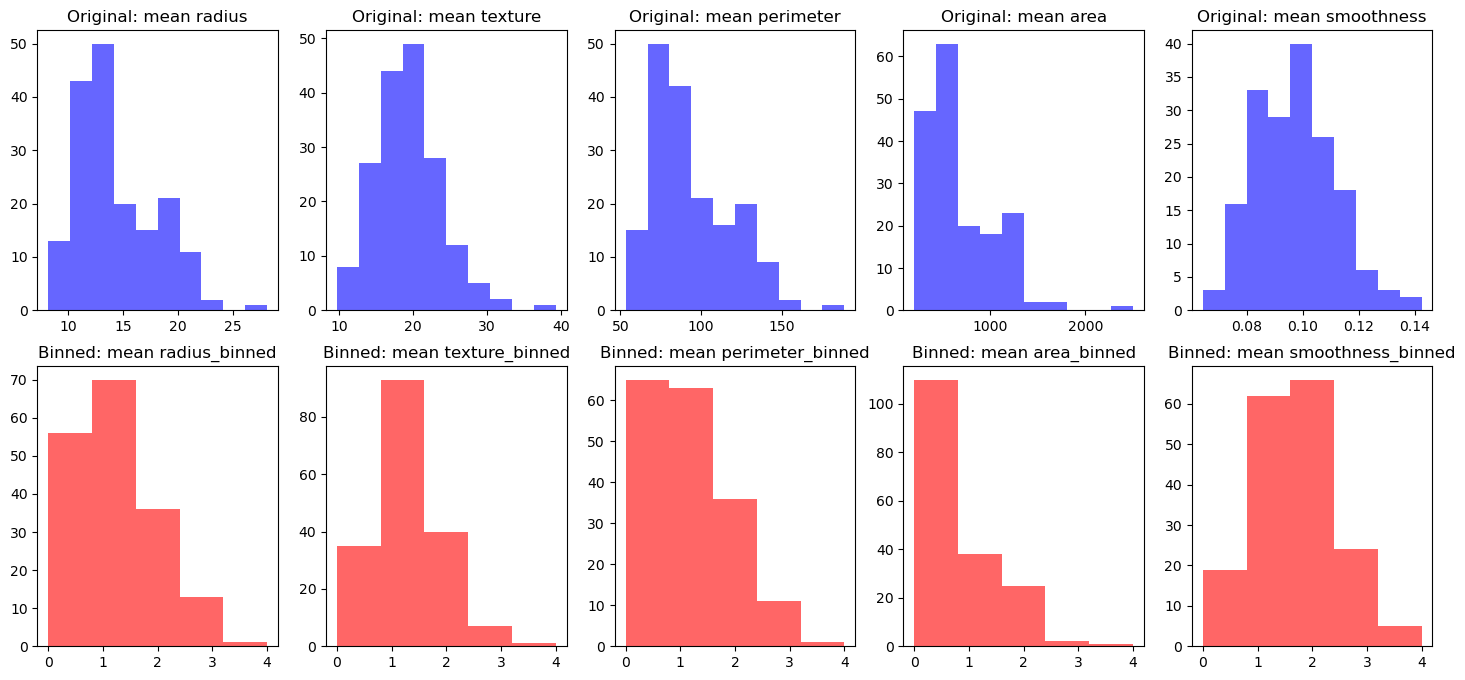

In [10]:
binner = KBinsDiscretizer(strategy='uniform',n_bins=5, encode= 'ordinal')
binner.fit_transform(df)
binned_df = pd.DataFrame(binner.fit_transform(df), columns=[col + '_binned' for col in df.columns])
num_cols = len(df.columns)


num_cols = len(df.columns)
ncols = 5  
nrows = 2  

fig, axes = plt.subplots(nrows, ncols, figsize = (18,8))


for i, col in enumerate(df.columns):
    axes[0, i].hist(df[col], bins=10, color="blue", alpha=0.6)
    axes[0, i].set_title(f"Original: {col}")


for i, col in enumerate(binned_df.columns):
    axes[1, i].hist(binned_df[col], bins=5, color="red", alpha=0.6)
    axes[1, i].set_title(f"Binned: {col}")

plt.tight_layout
plt.show()
